# Creation of a new dataset containing only hard items 

In [1]:
import json
pt = "/home/creux/Documents/AI/VTikz/VariabilityBenchmark/notebooks/manual_exploration/hard_ids.json"
hard_items = json.load(open(pt))

In [3]:
from datasets import load_dataset

ds = load_dataset("CharlyR/vtikz",split="benchmark")

In [6]:
kept_ids = set([id for (id,_) in hard_items])

In [ ]:
hard_ds = ds.filter(lambda row: row["id"] in kept_ids)

Filter: 100%|██████████| 100/100 [00:00<00:00, 234.20 examples/s]


## Exploration of hard dataset, and LLMs outputs on it

In [24]:
import sys
from datasets import load_dataset,concatenate_datasets


ds1 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_openaigpt5.2_pk_1_t_0.7_v1.63",split="tikz")
ds2 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_googlegemini3propreview_pk_1_t_0.7_v1.63",split="tikz")
ds_eval = concatenate_datasets([ds1,ds2])
ds_eval = ds_eval.filter(lambda row: row["id"] in kept_ids)
ds_eval = ds_eval.sort("id")
df = ds_eval.to_pandas()

Filter: 100%|██████████| 200/200 [00:01<00:00, 143.60 examples/s]


In [49]:
from IPython.display import HTML, display
import base64

def display_images_row(*img_jsons, margin=10):
    imgs = []
    for img in img_jsons:
        if img is None:
            continue
        b64 = base64.b64encode(img["bytes"]).decode("utf-8")
        imgs.append(
            f"<img src='data:image/png;base64,{b64}' "
            f"style='width:30vw; height:auto; margin-right:{margin}px;'>"
        )
    html = "<div style='display:flex; align-items:flex-start;'>" + "".join(imgs) + "</div>"
    display(HTML(html))


In [50]:
i=  0
i-=  1

Rotate the ears of the cow downward
cow_downward_ears



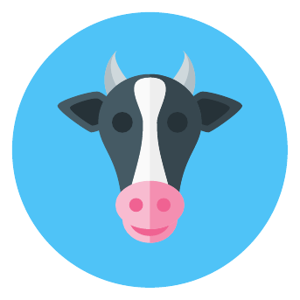
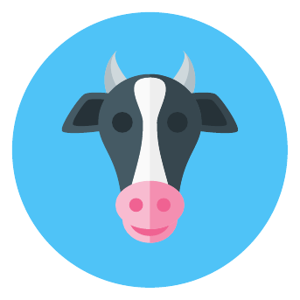
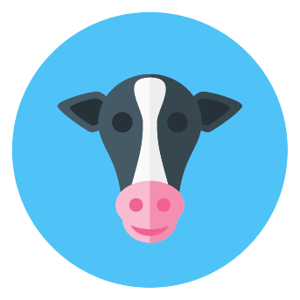

In [73]:
i+=1
row = df.iloc[i]
print(row["instruction"])
print(row["id"])
display_images_row(
    row["image_input"],
    row["image_solution"][0],
    row["images_result"][0],
)

In [23]:
df.columns

Index(['difficulty_ast', 'id', 'code', 'commented_code', 'instruction',
       'result_description', 'difficulty', 'modification_type', 'type',
       'patch', 'template_solution_code', 'code_solution', 'image_solution',
       'image_input'],
      dtype='object')